In [6]:
import os; import csv ; import numpy as np ; import matplotlib.pyplot as plt ; from pathlib import Path ; import pandas as pd      ; import B_WELL as WELL
with open(os.path.join(os.getcwd(), 'B_DATA.csv'),newline='') as CSV: data = np.array(list(  csv.reader(CSV,quoting = csv.QUOTE_NONNUMERIC)  ))   
OUT = Path("./OUT_Theis") ;OUT.mkdir(exist_ok=True)                          ; from scipy.optimize import curve_fit as FIT  # _______________ curve_fit _______________

In [7]:
Q=8176.49 ;Q=Q/(24*60) ;RR=91.44      ; TIME = data[:,0]   ; MED = data[:,1]   ; df1=pd.DataFrame(TIME);df2=pd.DataFrame(MED)  ;pe = pd.concat([df1, df2], axis=1)   
pe.columns = ["(sec)", "(meters)"]   ; pe.to_csv(OUT/ 'a_pe.csv')              ; tol = 1e-7   ; T=500;S=0.001;T=T/(24*60)

<font color='black'> **REF** <br> 
<font color='black'> 
$ 
\,\,\,\,\,\,\,      OBJ = \sum_{i=1}^{n} (s'_{mod}-s'_{meas})^2               \,\,\,\,\,\,\,\,\,\,\,\,\,\,
$
<font color='blue'> 
$ 
\,\,\,\,\,\,\,      T = \frac{Q}{4 \pi (H_0 - H)} *W(u)               \,\,\,\,\,\,\,\,\,\,\,\,\,\,
$
<font color='green'> 
$ 
\,\,\,\,\,\,\,      u = \frac{r^2S}{4Tt}              \,\,\,\,\,\,\,\,\,\,\,\,\,\,
$
<font color='orange'> 
$ 
\,\,\,\,\,\,\,      W(u) = \int_{u}^{\infty} \frac{e^{-a}}{a}\,da      \,\,\,\,\,\,\,\,\,\,\,\,\,\,
$
<font color='red'> 
$ 
\,\,\,\,\,\,\,      W(u) = -0.577 - ln(u) + u -\frac{u^2}{2*2!} + \frac{u^3}{3*3!} -\frac{u^4}{4*4!} + ...  
$

In [8]:
def FUNC(t ,Transmissivity ,Storativity):
    FAT     = np.zeros(len(t))
    for ii in range(0, len(t)):        UU = ((RR**2)*Storativity)/(4*Transmissivity *t[ii])                  ; FAT[ii] = WELL.FXN(UU,tol)*Q/( 4*Transmissivity*np.pi )      
    return FAT

[TT ,SS], junk = FIT(FUNC, TIME, MED, p0=([T,S]), bounds=(0, np.inf))    ;FIM = ( (RR**2)*SS )/(4*TT*TIME)   ; MOD2 = list(map(lambda FIM: WELL.FXN(FIM,tol)*Q/(4*TT*np.pi), FIM))
UV = ((RR**2)*S) / (4*T*TIME)                                                                                ; MOD1 = list(map(lambda UV: WELL.FXN(UV,tol) * Q / ( 4*T*np.pi ), UV ))   

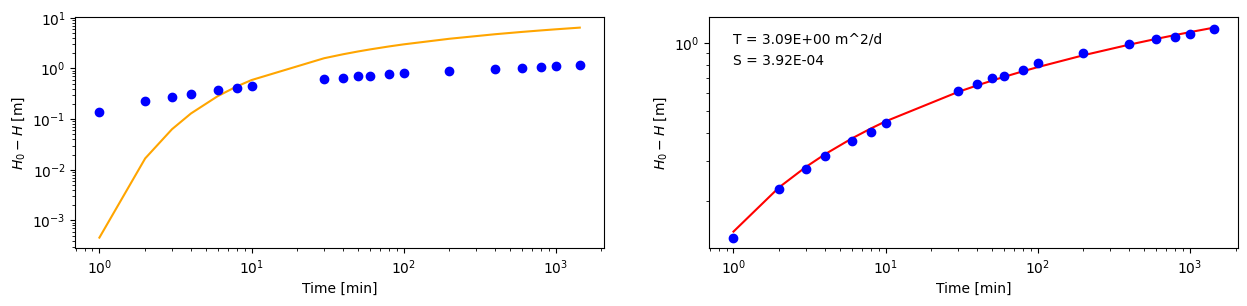

In [9]:
fig = plt.figure(figsize=(15, 3))                    
ax = fig.add_subplot(121)                     ; plt.loglog(TIME, MOD1,'orange',TIME, MED,'bo', )  ; plt.xlabel('Time [min]')   ; plt.ylabel('$H_0-H$ [m]') 
ax = fig.add_subplot(122)                     ; plt.loglog(TIME, MOD2,'red',TIME, MED,'bo', )     ; plt.xlabel('Time [min]')   ; plt.ylabel('$H_0-H$ [m]')
Tstring = "T = "+format(TT,'.2E') +" m^2/d"   ; Sstring = "S = " + format(SS,'.2E')               ; plt.annotate(Tstring, xy=(1, 1)) ; plt.annotate(Sstring, xy=(1,0.8)) ; plt.show()

In [10]:
OBJ1 = np.sum(np.square(MOD1 - MED))   ; OBJ2 = np.sum(np.square(MED - MOD2))            ; print('OBJ1 =',int(OBJ1), ', OBJ2 =',round(OBJ2,3), ', T = ', int(TT),', S = ', SS) 

OBJ1 = 127 , OBJ2 = 0.004 , T =  3 , S =  0.00039243449304818457
